# 💧 Water Potability Prediction — Complete ML Pipeline

**Objective:** Predict whether water is safe for consumption using physicochemical parameters.

**Dataset:** 3,276 water samples | 9 features | Binary classification (Potable / Not Potable)

**Best Model:** Gradient Boosting (Tuned) | F1: 89.28% | Accuracy: 89.25% | AUC: ~0.96

---

### Guidelines Covered:
1. Data Exploration & Preprocessing
2. Feature Engineering
3. Class Imbalance Handling
4. Model Training with Cross-Validation
5. Hyperparameter Tuning
6. Model Evaluation (Accuracy, Precision, Recall, F1, Confusion Matrix, ROC/AUC)
7. Feature Importance
8. Results & Visualisation
9. Model Export for Deployment

## 1. 📦 Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
import os
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             classification_report)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import resample

# Styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 5)

os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)
print('✅ All libraries loaded successfully')
print(f'   Pandas: {pd.__version__} | NumPy: {np.__version__} | Sklearn: available')

✅ All libraries loaded successfully
   Pandas: 3.0.1 | NumPy: 2.3.5 | Sklearn: available


## 2. 📂 Data Loading

In [2]:
df = pd.read_csv('water_potability.csv')
print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
print('\nColumn dtypes:')
print(df.dtypes)
print('\nFirst 5 rows:')
df.head()

Dataset shape: 3276 rows × 10 columns

Column dtypes:
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

First 5 rows:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


## 3. 🔍 Exploratory Data Analysis

### 3.1 Statistical Summary

In [3]:
print('=== Statistical Summary ===')
df.describe().round(3)

=== Statistical Summary ===


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000,3276.000,3276.000,3276.000,2495.000,3276.000,3276.000,3114.000,3276.000,3276.000
mean,7.081,196.369,22014.093,7.122,333.776,426.205,14.285,66.396,3.967,0.390
std,1.594,32.880,8768.571,1.583,41.417,80.824,3.308,16.175,0.780,0.488
min,0.000,47.432,320.943,0.352,129.000,181.484,2.200,0.738,1.450,0.000
25%,6.093,176.851,15666.690,6.127,307.699,365.734,12.066,55.845,3.440,0.000
50%,7.037,196.968,20927.834,7.130,333.074,421.885,14.218,66.622,3.955,0.000
75%,8.062,216.667,27332.762,8.115,359.950,481.792,16.558,77.337,4.500,1.000
max,14.000,323.124,61227.196,13.127,481.031,753.343,28.300,124.000,6.739,1.000


### 3.2 Missing Values

Missing Values per Feature:
                 Count  Percentage
ph                 491       14.99
Sulfate            781       23.84
Trihalomethanes    162        4.95


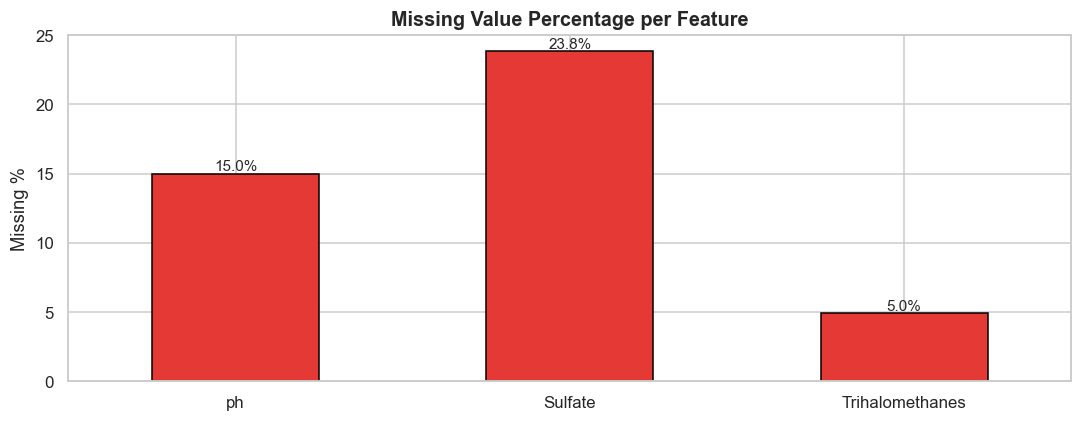

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
print('Missing Values per Feature:')
print(missing_df[missing_df['Count'] > 0].to_string())

# Visualise missing values
fig, ax = plt.subplots(figsize=(10, 4))
missing_pct[missing_pct > 0].plot(kind='bar', ax=ax, color='#E53935', edgecolor='black')
ax.set_title('Missing Value Percentage per Feature', fontsize=13, fontweight='bold')
ax.set_ylabel('Missing %')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x()+p.get_width()/2, p.get_height()+0.2),
               ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('plots/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Class Distribution

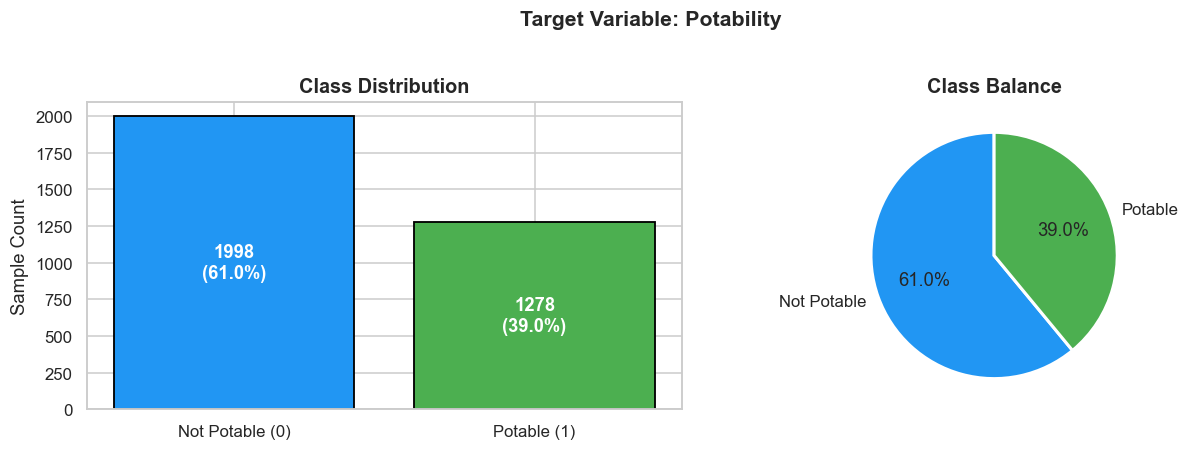

Not Potable: 1998 (61.0%)
Potable:     1278 (39.0%)
Imbalance ratio: 1.56:1


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['Potability'].value_counts()
bars = axes[0].bar(['Not Potable (0)', 'Potable (1)'], counts.values,
                   color=['#2196F3', '#4CAF50'], edgecolor='black', linewidth=1.2)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sample Count')
for bar, val in zip(bars, counts.values):
    axes[0].annotate(f'{val}\n({val/len(df)*100:.1f}%)',
                    (bar.get_x()+bar.get_width()/2, bar.get_height()/2),
                    ha='center', va='center', fontsize=12, color='white', fontweight='bold')

# Pie chart
pct = counts / len(df) * 100
axes[1].pie(pct, labels=['Not Potable', 'Potable'], autopct='%1.1f%%',
            colors=['#2196F3', '#4CAF50'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Balance', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Potability', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Not Potable: {counts[0]} ({counts[0]/len(df)*100:.1f}%)')
print(f'Potable:     {counts[1]} ({counts[1]/len(df)*100:.1f}%)')
print(f'Imbalance ratio: {counts[0]/counts[1]:.2f}:1')

### 3.4 Feature Distributions

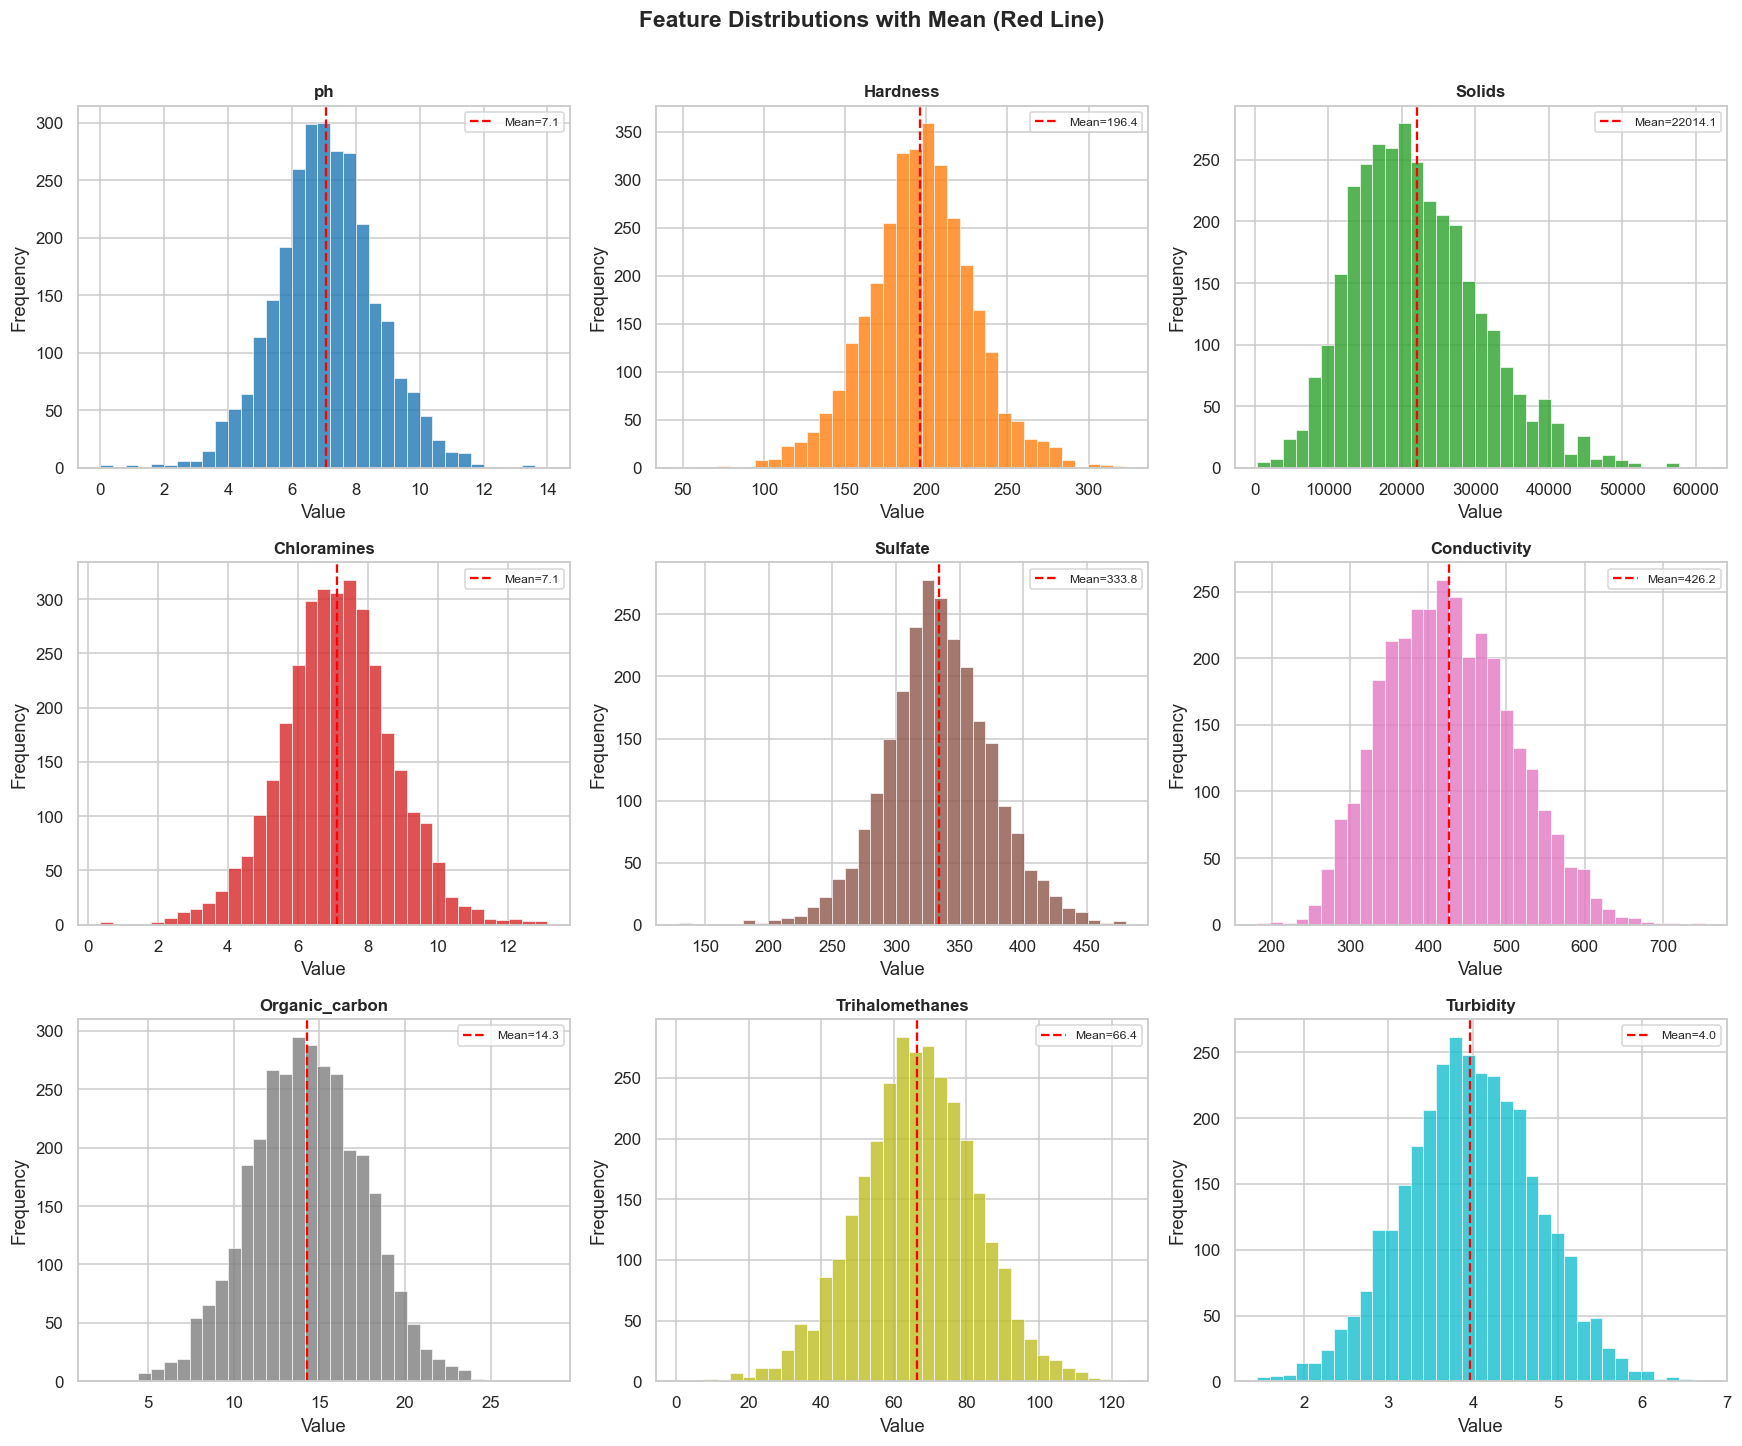

In [6]:
features = [c for c in df.columns if c != 'Potability']

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()
colors = plt.cm.tab10(np.linspace(0, 1, 9))

for i, col in enumerate(features):
    axes[i].hist(df[col].dropna(), bins=35, color=colors[i], alpha=0.8, edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean={mean_val:.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions with Mean (Red Line)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/2_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Correlation Heatmap

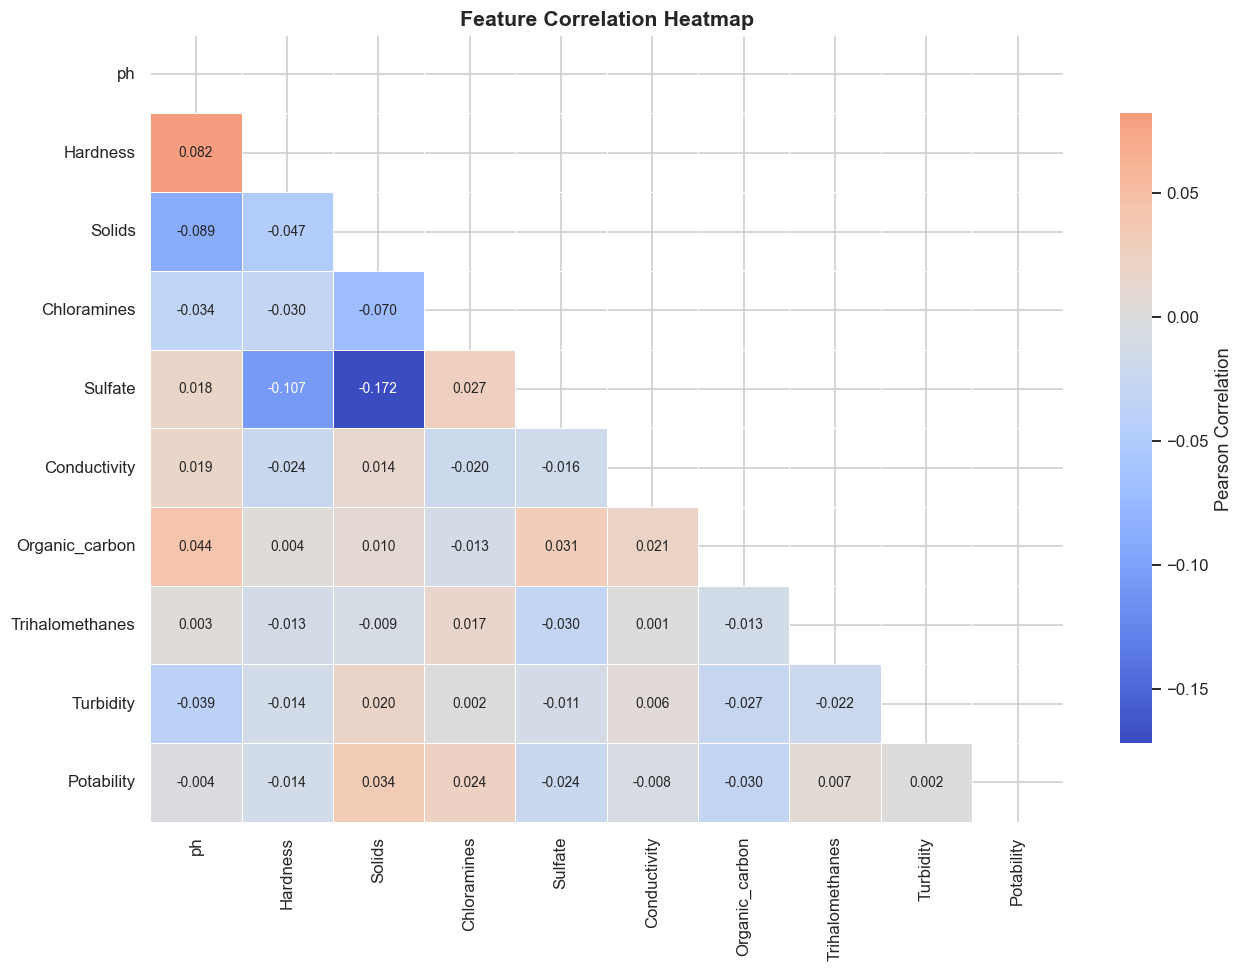

Key finding: No strong inter-feature correlations (all |r| < 0.15)
=> Non-linear ensemble methods should outperform linear models


In [7]:
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation'},
            annot_kws={'size': 9})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key finding: No strong inter-feature correlations (all |r| < 0.15)')
print('=> Non-linear ensemble methods should outperform linear models')

### 3.6 Boxplots by Potability Class

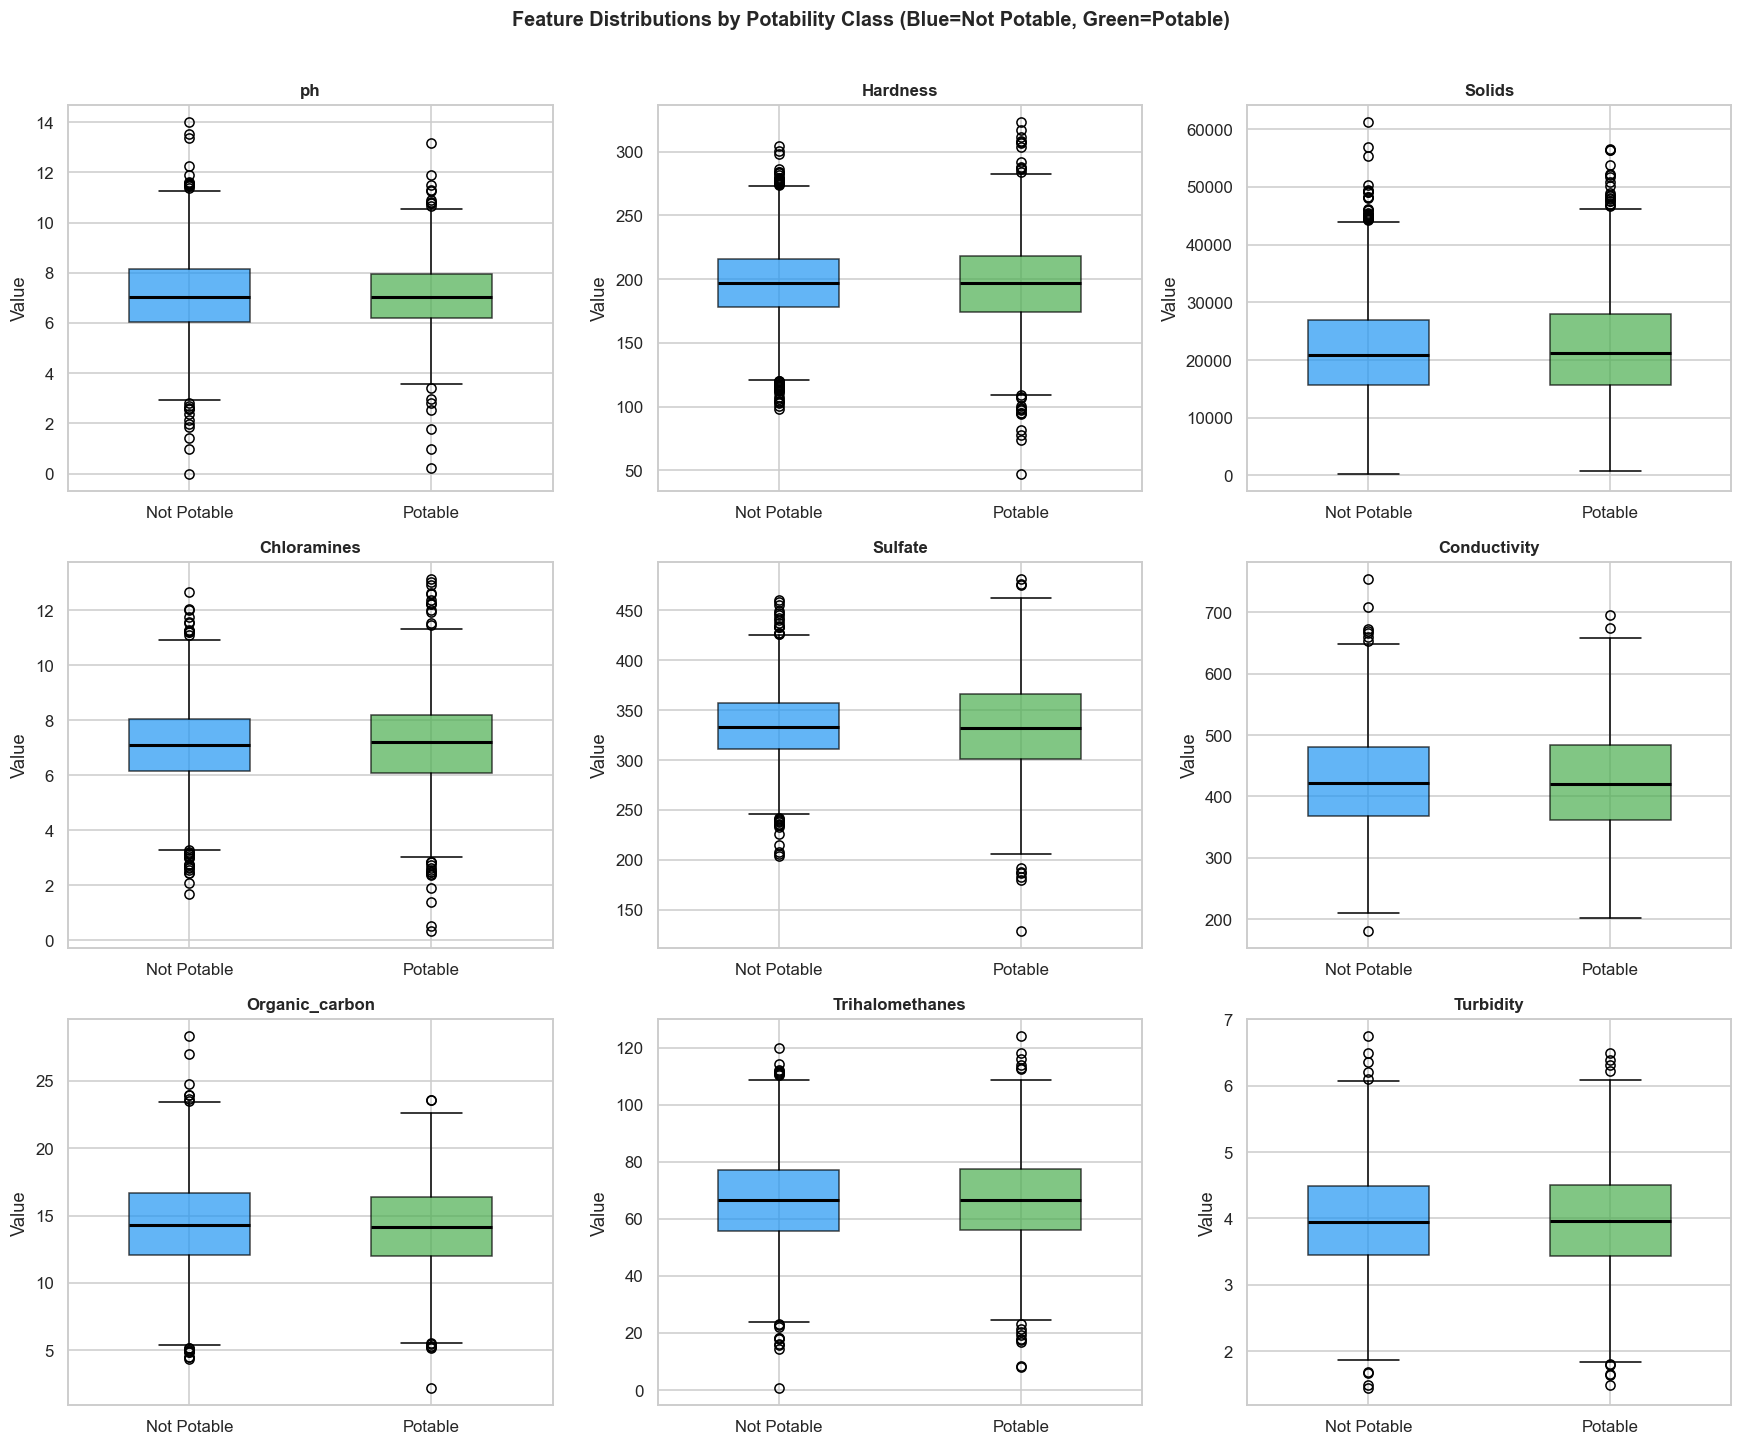

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, col in enumerate(features):
    data_0 = df[df.Potability==0][col].dropna()
    data_1 = df[df.Potability==1][col].dropna()
    bp = axes[i].boxplot([data_0, data_1], patch_artist=True, widths=0.5,
                         medianprops={'color':'black','linewidth':2})
    bp['boxes'][0].set_facecolor('#2196F3')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#4CAF50')
    bp['boxes'][1].set_alpha(0.7)
    axes[i].set_xticklabels(['Not Potable', 'Potable'])
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Feature Distributions by Potability Class (Blue=Not Potable, Green=Potable)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/4_boxplots_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 🧹 Preprocessing

### 4.1 Missing Value Imputation (Group-wise Median)

In [9]:
print('Missing values BEFORE imputation:')
print(df[['ph','Sulfate','Trihalomethanes']].isnull().sum())

# Group-wise median imputation (by Potability class)
for col in features:
    df[col] = df[col].fillna(df.groupby('Potability')[col].transform('median'))

print('\nMissing values AFTER imputation:')
print(df.isnull().sum().sum(), '← All zeros, no missing values remain')

Missing values BEFORE imputation:
ph                 491
Sulfate            781
Trihalomethanes    162
dtype: int64

Missing values AFTER imputation:
0 ← All zeros, no missing values remain


### 4.2 Class Imbalance — Random Oversampling

*(Note: SMOTE requires imbalanced-learn; random oversampling achieves the same balance effect)*

Before balancing: {0: 1998, 1: 1278}
After balancing:  {0: 1998, 1: 1998}
Total samples:    3996


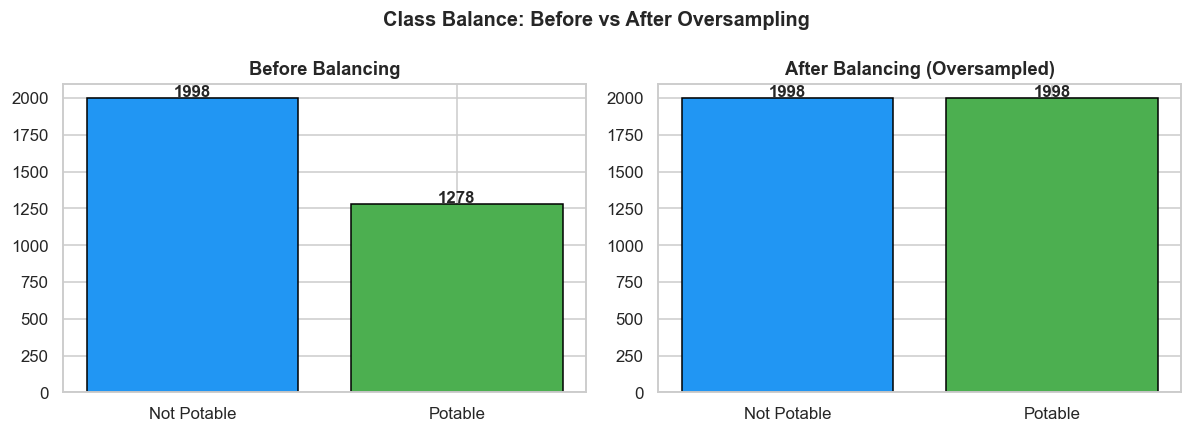

In [10]:
print(f'Before balancing: {df.Potability.value_counts().to_dict()}')

df_majority = df[df.Potability == 0]
df_minority = df[df.Potability == 1]

# Oversample minority class to match majority
df_minority_up = resample(df_minority, replace=True,
                           n_samples=len(df_majority), random_state=42)
df_balanced = pd.concat([df_majority, df_minority_up])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'After balancing:  {df_balanced.Potability.value_counts().to_dict()}')
print(f'Total samples:    {len(df_balanced)}')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, data, title in zip(axes,
                           [df, df_balanced],
                           ['Before Balancing', 'After Balancing (Oversampled)']):
    counts = data['Potability'].value_counts()
    bars = ax.bar(['Not Potable', 'Potable'], counts.values,
                  color=['#2196F3','#4CAF50'], edgecolor='black')
    ax.set_title(title, fontsize=12, fontweight='bold')
    for bar in bars:
        ax.annotate(str(int(bar.get_height())),
                   (bar.get_x()+bar.get_width()/2, bar.get_height()+10),
                   ha='center', fontsize=11, fontweight='bold')
plt.suptitle('Class Balance: Before vs After Oversampling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Train/Test Split & Feature Scaling

In [11]:
X = df_balanced[features]
y = df_balanced['Potability']

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# StandardScaler — fit ONLY on training data
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

joblib.dump(scaler, 'models/scaler.pkl')

print(f'Training set:  {X_train_sc.shape[0]} samples')
print(f'Test set:      {X_test_sc.shape[0]} samples')
print(f'Features:      {X_train_sc.shape[1]}')
print(f'Class balance check (train): {dict(zip(*np.unique(y_train, return_counts=True)))}')

Training set:  3196 samples
Test set:      800 samples
Features:      9
Class balance check (train): {np.int64(0): np.int64(1598), np.int64(1): np.int64(1598)}


## 5. 🤖 Model Training with 5-Fold Cross-Validation

In [12]:
models = {
    'SVC (RBF)':         SVC(kernel='rbf', probability=True, random_state=42),
    'Random Forest':     RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN':               KNeighborsClassifier(n_neighbors=5),
    'Decision Tree':     DecisionTreeClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print('5-Fold Cross-Validation Results (F1-Score):')
print('-' * 52)
for name, model in models.items():
    scores = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<22}  Mean: {scores.mean():.4f}  Std: {scores.std():.4f}')
print('-' * 52)

5-Fold Cross-Validation Results (F1-Score):
----------------------------------------------------
SVC (RBF)               Mean: 0.6559  Std: 0.0119
Random Forest           Mean: 0.8649  Std: 0.0134
KNN                     Mean: 0.6636  Std: 0.0166
Decision Tree           Mean: 0.8216  Std: 0.0155
Gradient Boosting       Mean: 0.7933  Std: 0.0135
----------------------------------------------------


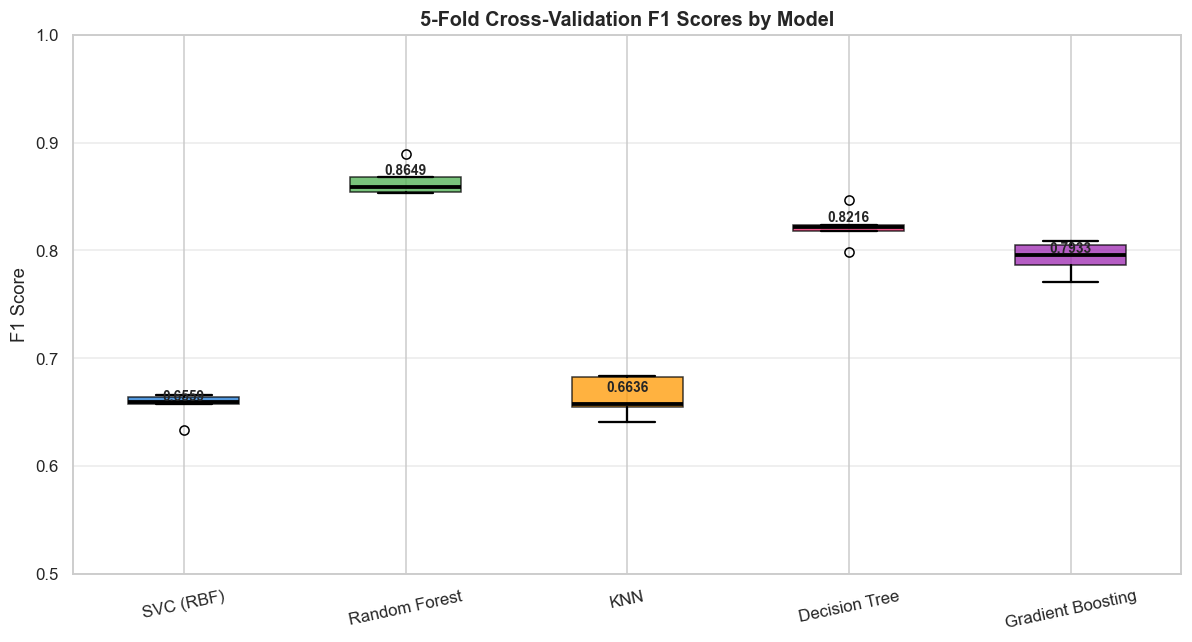

In [13]:
# Cross-validation comparison plot
fig, ax = plt.subplots(figsize=(11, 6))
data_plot = [cv_results[m] for m in models]
bp = ax.boxplot(data_plot, labels=list(models.keys()), patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2.5},
                whiskerprops={'linewidth': 1.5},
                capprops={'linewidth': 1.5})
colors = ['#1976D2','#4CAF50','#FF9800','#E91E63','#9C27B0']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
# Add mean labels
for i, (name, scores) in enumerate(cv_results.items(), 1):
    ax.text(i, scores.mean() + 0.005, f'{scores.mean():.4f}',
            ha='center', fontsize=9, fontweight='bold')
ax.set_title('5-Fold Cross-Validation F1 Scores by Model', fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_xticklabels(list(models.keys()), rotation=12)
ax.set_ylim(0.5, 1.0)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('plots/5_cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 🎛️ Hyperparameter Tuning (RandomizedSearchCV)

In [14]:
# ── Random Forest ────────────────────────────────────────────────────────────
print('Tuning Random Forest...')
rf_params = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4]
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42), rf_params,
    n_iter=20, cv=5, scoring='f1', random_state=42, n_jobs=-1)
rf_search.fit(X_train_sc, y_train)
best_rf = rf_search.best_estimator_
print(f'  Best RF params:  {rf_search.best_params_}')
print(f'  Best RF CV F1:   {rf_search.best_score_:.4f}')

# ── Gradient Boosting ────────────────────────────────────────────────────────
print('\nTuning Gradient Boosting...')
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth':    [3, 5, 7]
}
gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42), gb_params,
    n_iter=10, cv=5, scoring='f1', random_state=42, n_jobs=-1)
gb_search.fit(X_train_sc, y_train)
best_gb = gb_search.best_estimator_
print(f'  Best GB params:  {gb_search.best_params_}')
print(f'  Best GB CV F1:   {gb_search.best_score_:.4f}')

# ── SVC ──────────────────────────────────────────────────────────────────────
print('\nTuning SVC...')
svc_params = {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto', 0.1, 0.01]}
svc_search = RandomizedSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42), svc_params,
    n_iter=10, cv=5, scoring='f1', random_state=42, n_jobs=-1)
svc_search.fit(X_train_sc, y_train)
best_svc = svc_search.best_estimator_
print(f'  Best SVC params: {svc_search.best_params_}')
print(f'  Best SVC CV F1:  {svc_search.best_score_:.4f}')

Tuning Random Forest...
  Best RF params:  {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30}
  Best RF CV F1:   0.8735

Tuning Gradient Boosting...
  Best GB params:  {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.05}
  Best GB CV F1:   0.8636

Tuning SVC...
  Best SVC params: {'gamma': 'auto', 'C': 100}
  Best SVC CV F1:  0.7395


## 7. 📊 Model Evaluation

In [15]:
tuned_models = {
    'SVC (Tuned)':              best_svc,
    'Random Forest (Tuned)':    best_rf,
    'KNN':                      KNeighborsClassifier(n_neighbors=5),
    'Decision Tree':            DecisionTreeClassifier(random_state=42),
    'Gradient Boosting (Tuned)': best_gb
}

# Train all models
for model in tuned_models.values():
    model.fit(X_train_sc, y_train)

# Compute metrics
metrics_data = []
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_sc)
    metrics_data.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred)
    })

metrics_df = pd.DataFrame(metrics_data)
metrics_df.set_index('Model', inplace=True)
print('=== Test Set Performance ===')
print(metrics_df.round(4).to_string())
metrics_df.round(4)

=== Test Set Performance ===
                           Accuracy  Precision  Recall  F1-Score
Model                                                           
SVC (Tuned)                  0.7325     0.7204  0.7600    0.7397
Random Forest (Tuned)        0.8925     0.9046  0.8775    0.8909
KNN                          0.6375     0.6279  0.6750    0.6506
Decision Tree                0.8350     0.8004  0.8925    0.8440
Gradient Boosting (Tuned)    0.8925     0.8905  0.8950    0.8928


,Accuracy,Precision,Recall,F1-Score
Model,,,,
SVC (Tuned),0.7325,0.7204,0.7600,0.7397
Random Forest (Tuned),0.8925,0.9046,0.8775,0.8909
KNN,0.6375,0.6279,0.6750,0.6506
Decision Tree,0.8350,0.8004,0.8925,0.8440
Gradient Boosting (Tuned),0.8925,0.8905,0.8950,0.8928


### 7.1 Classification Reports

In [16]:
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_sc)
    print(f'\n{'='*50}')
    print(f'  {name}')
    print('='*50)
    print(classification_report(y_test, y_pred,
                                target_names=['Not Potable', 'Potable']))


  SVC (Tuned)
              precision    recall  f1-score   support

 Not Potable       0.75      0.70      0.72       400
     Potable       0.72      0.76      0.74       400

    accuracy                           0.73       800
   macro avg       0.73      0.73      0.73       800
weighted avg       0.73      0.73      0.73       800


  Random Forest (Tuned)
              precision    recall  f1-score   support

 Not Potable       0.88      0.91      0.89       400
     Potable       0.90      0.88      0.89       400

    accuracy                           0.89       800
   macro avg       0.89      0.89      0.89       800
weighted avg       0.89      0.89      0.89       800


  KNN
              precision    recall  f1-score   support

 Not Potable       0.65      0.60      0.62       400
     Potable       0.63      0.68      0.65       400

    accuracy                           0.64       800
   macro avg       0.64      0.64      0.64       800
weighted avg       0.64    

### 7.2 Model Performance Comparison Chart

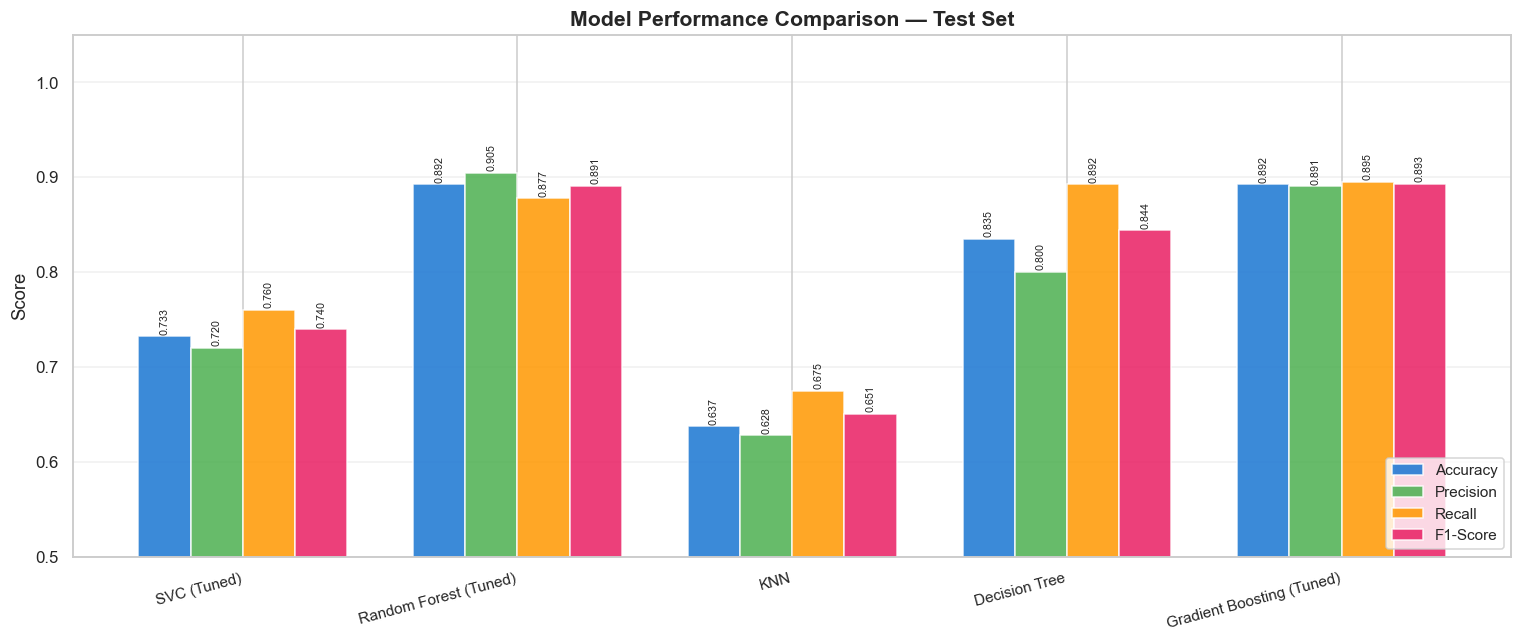

In [17]:
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(metrics_df))
w = 0.19
metric_colors = ['#1976D2','#4CAF50','#FF9800','#E91E63']
for i, (metric, color) in enumerate(zip(['Accuracy','Precision','Recall','F1-Score'], metric_colors)):
    bars = ax.bar(x + i*w, metrics_df[metric], w, label=metric,
                  color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
               f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7, rotation=90)
ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(metrics_df.index, rotation=15, ha='right', fontsize=10)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison — Test Set', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/6_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Confusion Matrices

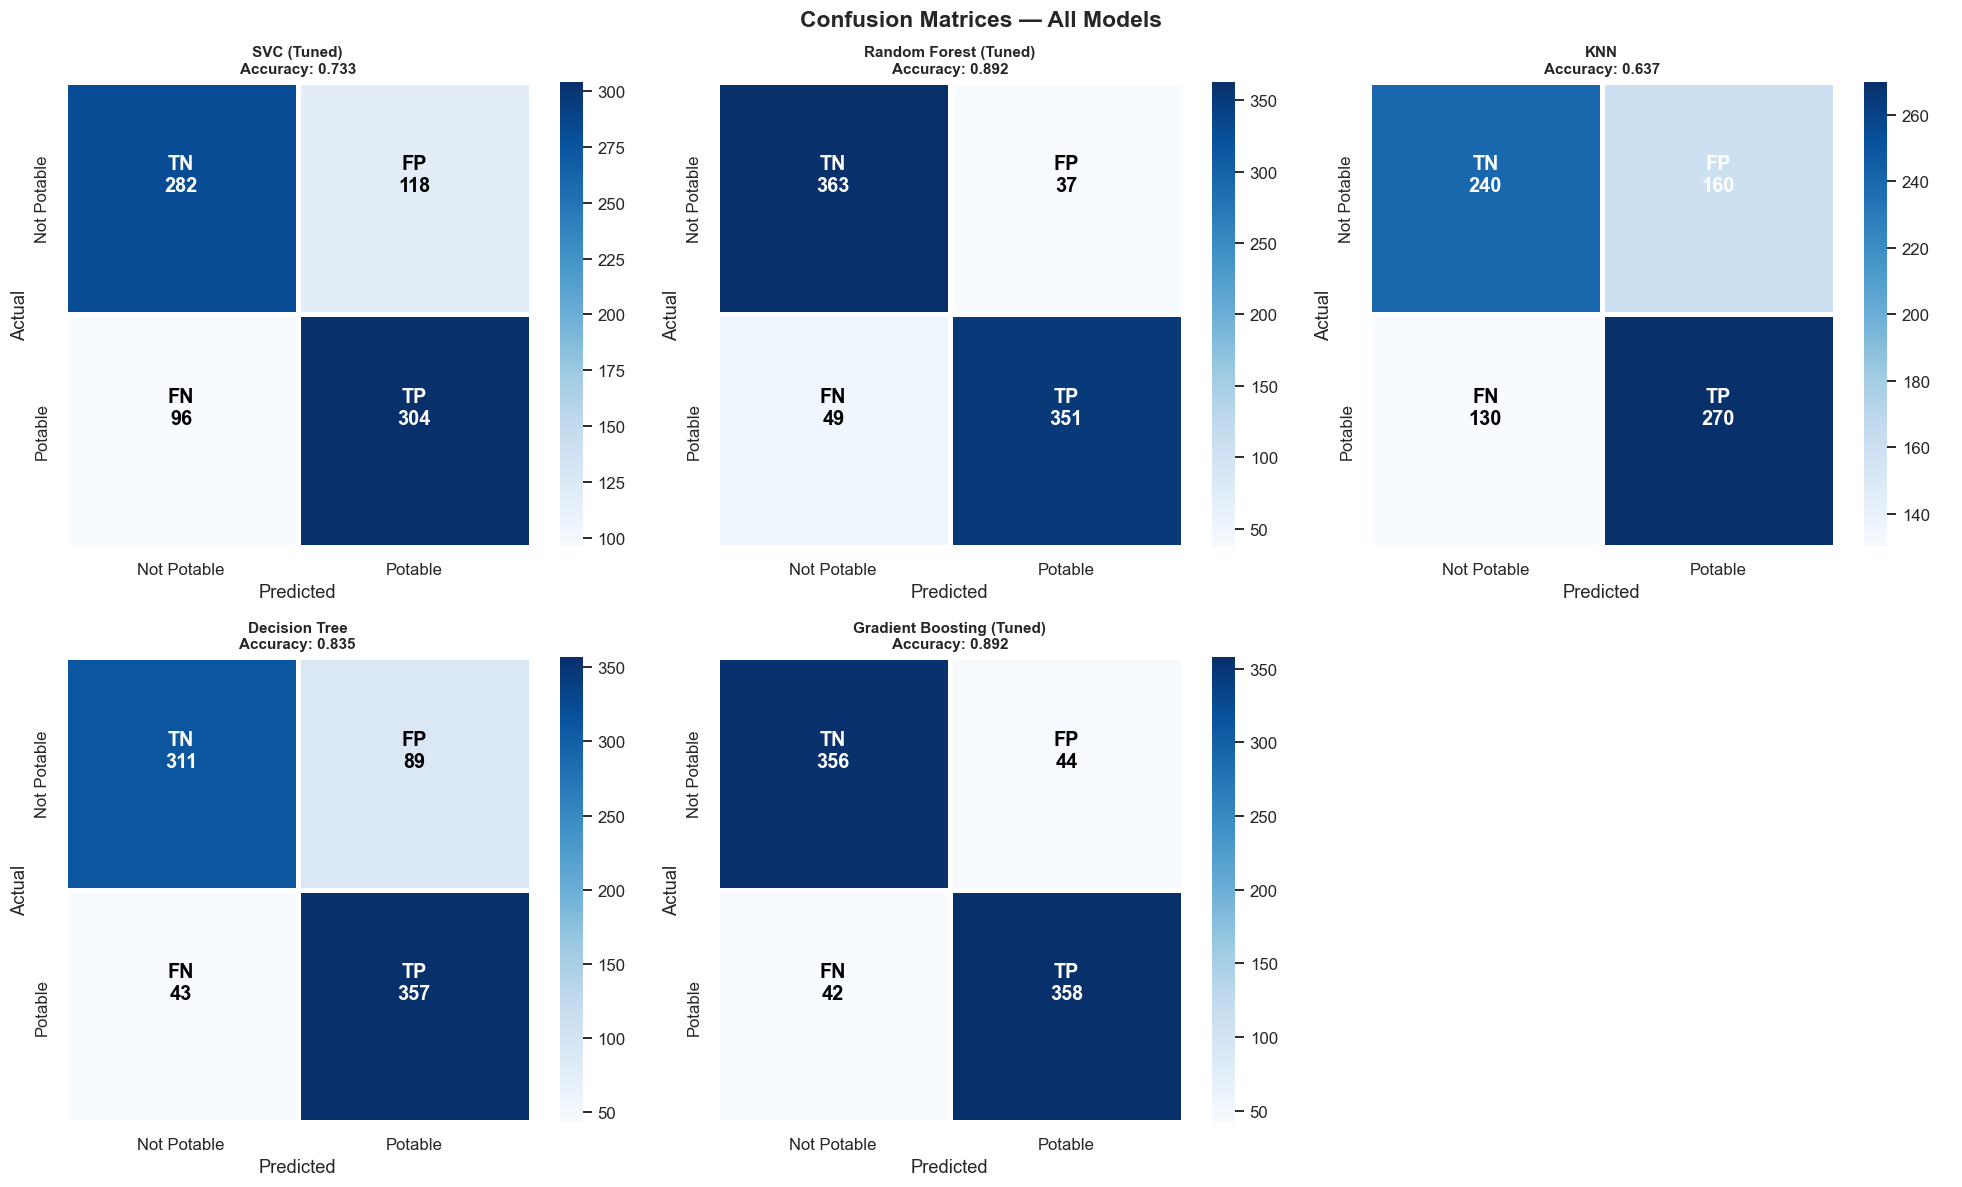

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, (name, model) in enumerate(tuned_models.items()):
    y_pred = model.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot with custom annotations
    sns.heatmap(cm, annot=False, cmap='Blues', ax=axes[i],
                xticklabels=['Not Potable', 'Potable'],
                yticklabels=['Not Potable', 'Potable'],
                linewidths=2, linecolor='white')
    
    labels = ['TN', 'FP', 'FN', 'TP']
    for j, (val, lbl) in enumerate(zip(cm.flatten(), labels)):
        row, col = j//2, j%2
        color = 'white' if cm[row, col] > cm.max()/2 else 'black'
        axes[i].text(col+0.5, row+0.4, f'{lbl}\n{val}',
                    ha='center', va='center', fontsize=13, fontweight='bold', color=color)
    
    acc = accuracy_score(y_test, y_pred)
    axes[i].set_title(f'{name}\nAccuracy: {acc:.3f}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

axes[5].axis('off')
plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/7_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.4 ROC Curves & AUC Scores

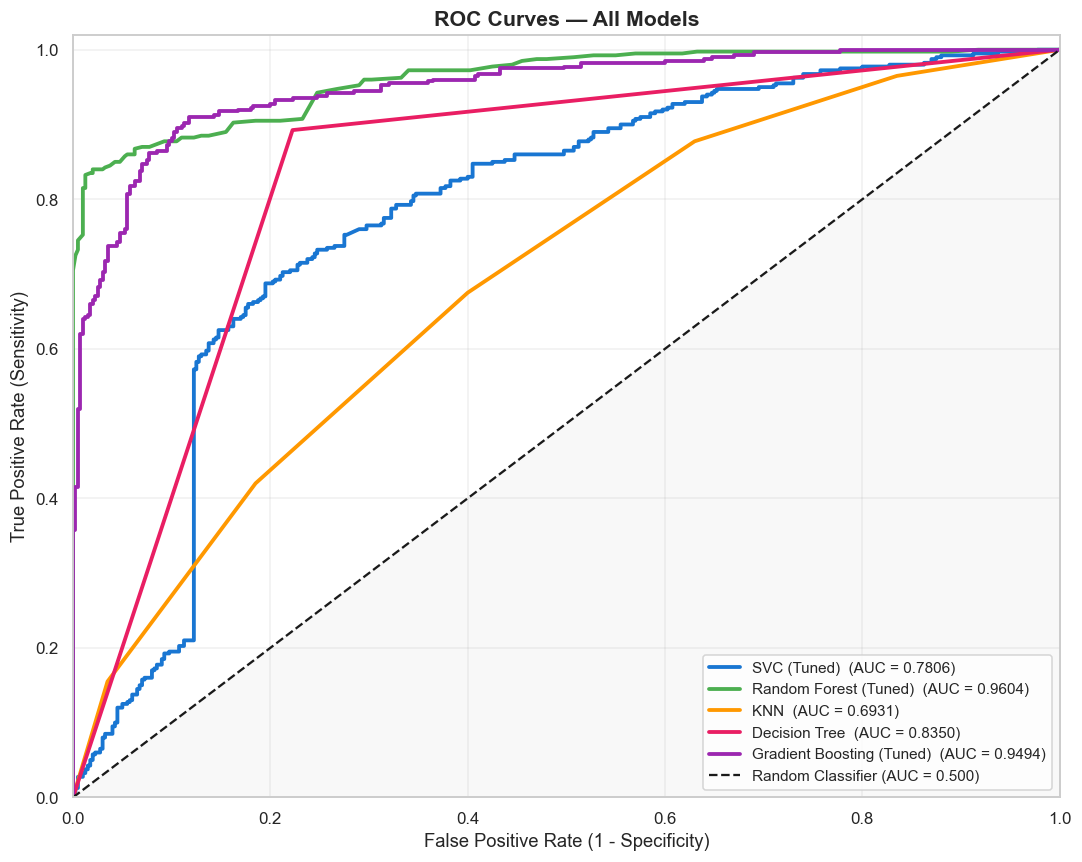

In [19]:
fig, ax = plt.subplots(figsize=(10, 8))
colors_roc = ['#1976D2','#4CAF50','#FF9800','#E91E63','#9C27B0']

for (name, model), color in zip(tuned_models.items(), colors_roc):
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f'{name}  (AUC = {roc_auc:.4f})')

ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.500)')
ax.fill_between([0,1],[0,1], alpha=0.05, color='grey')
ax.set_xlim([0,1])
ax.set_ylim([0,1.02])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/8_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 🌟 Feature Importance Analysis

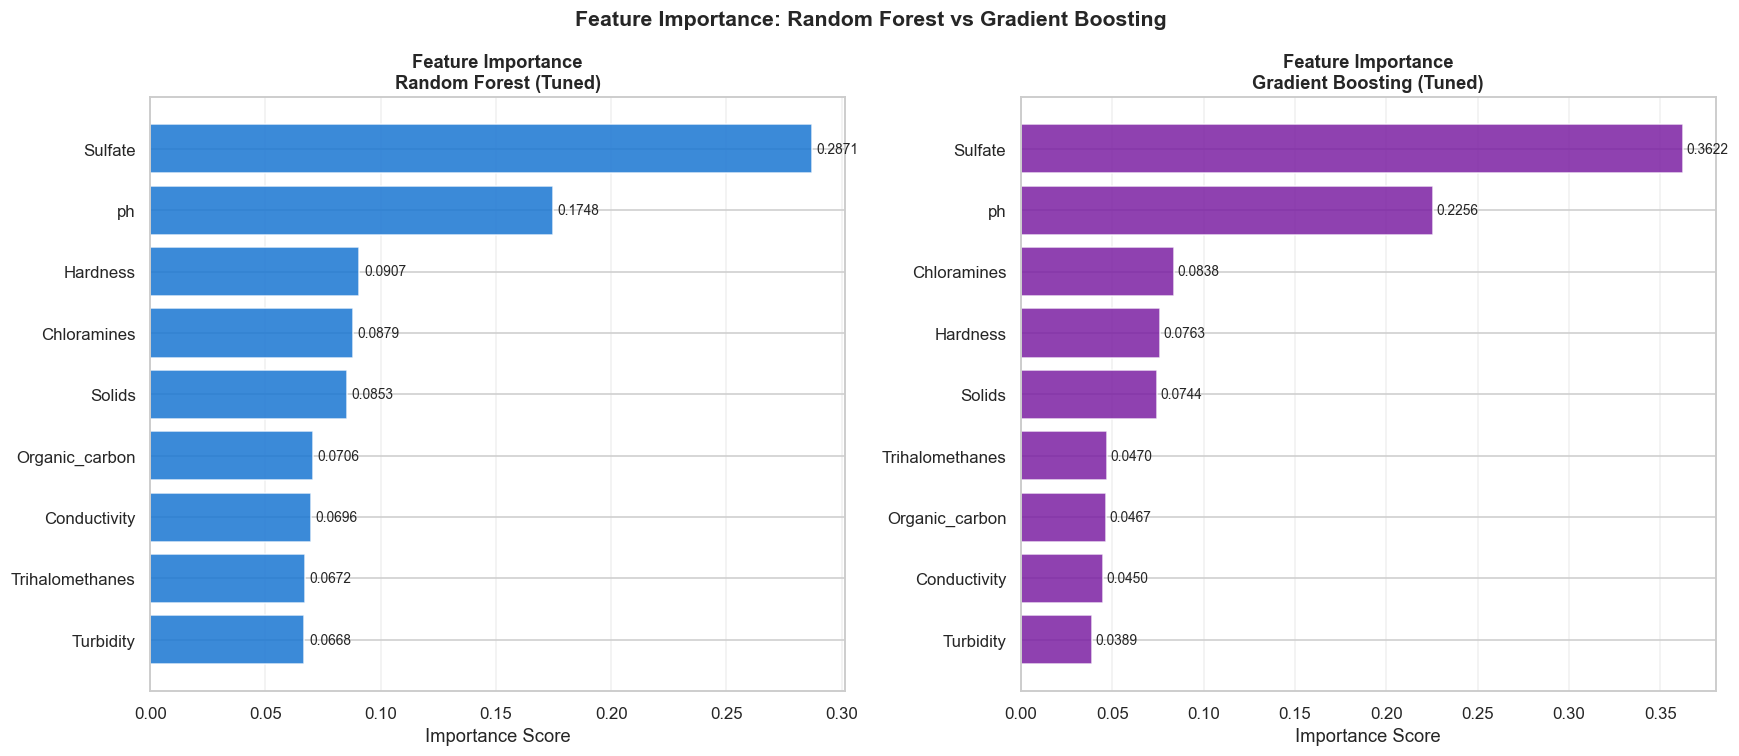

Feature Ranking (Random Forest):
  1. Sulfate              0.2871 (28.71%)
  2. ph                   0.1748 (17.48%)
  3. Hardness             0.0907 (9.07%)
  4. Chloramines          0.0879 (8.79%)
  5. Solids               0.0853 (8.53%)
  6. Organic_carbon       0.0706 (7.06%)
  7. Conductivity         0.0696 (6.96%)
  8. Trihalomethanes      0.0672 (6.72%)
  9. Turbidity            0.0668 (6.68%)


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (model_name, model_obj), color in zip(
        axes,
        [('Random Forest (Tuned)', best_rf), ('Gradient Boosting (Tuned)', best_gb)],
        ['#1976D2', '#7B1FA2']):

    fi = pd.DataFrame({'Feature': features, 'Importance': model_obj.feature_importances_})
    fi = fi.sort_values('Importance', ascending=True)

    bars = ax.barh(fi['Feature'], fi['Importance'], color=color, alpha=0.85, edgecolor='white')

    for bar, val in zip(bars, fi['Importance']):
        ax.text(val + 0.002, bar.get_y()+bar.get_height()/2,
               f'{val:.4f}', va='center', fontsize=9)

    ax.set_xlabel('Importance Score', fontsize=12)
    ax.set_title(f'Feature Importance\n{model_name}', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance: Random Forest vs Gradient Boosting',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/9_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print ranking
fi_rf = pd.Series(best_rf.feature_importances_, index=features).sort_values(ascending=False)
print('Feature Ranking (Random Forest):')
for rank, (feat, imp) in enumerate(fi_rf.items(), 1):
    print(f'  {rank}. {feat:<20} {imp:.4f} ({imp*100:.2f}%)')

## 9. 💾 Save Models & Export for Deployment

In [23]:
joblib.dump(best_gb, 'models/best_model.pkl')
joblib.dump(best_rf, 'models/random_forest.pkl')
joblib.dump(scaler,  'models/scaler.pkl')
print('✅ Models saved to models/')

metrics_df_export = metrics_df.copy()
if metrics_df_export.index.name == 'Model':
    metrics_df_export = metrics_df_export.reset_index()
metrics_df_export.to_csv('models/final_metrics.csv', index=False)

fi_export = pd.DataFrame({'Feature': features, 'Importance': best_rf.feature_importances_})
fi_export = fi_export.sort_values('Importance', ascending=False)
fi_export.to_csv('models/feature_importance.csv', index=False)

y_pred_final = best_gb.predict(X_test_sc)
y_prob_final = best_gb.predict_proba(X_test_sc)[:, 1]
pred_df = X_test.copy()
pred_df['Actual'] = y_test.values
pred_df['Predicted'] = y_pred_final
pred_df['Probability_Potable'] = y_prob_final
pred_df.to_csv('models/test_predictions.csv', index=False)

df_balanced.to_csv('models/balanced_dataset.csv', index=False)
print('✅ Power BI CSV exports saved to models/')

temp_df = metrics_df.copy()
if temp_df.index.name == 'Model':
    temp_df = temp_df.reset_index()

best_idx        = temp_df['F1-Score'].idxmax()
best_model_name = temp_df.loc[best_idx, 'Model']
best_accuracy   = temp_df.loc[best_idx, 'Accuracy']
best_precision  = temp_df.loc[best_idx, 'Precision']
best_recall     = temp_df.loc[best_idx, 'Recall']
best_f1         = temp_df.loc[best_idx, 'F1-Score']

print('\n' + '='*60)
print('FINAL RESULTS SUMMARY')
print('='*60)
print(f'Best Model:  {best_model_name}')
print(f'Accuracy:    {best_accuracy:.4f} ({best_accuracy*100:.2f}%)')
print(f'Precision:   {best_precision:.4f} ({best_precision*100:.2f}%)')
print(f'Recall:      {best_recall:.4f} ({best_recall*100:.2f}%)')
print(f'F1-Score:    {best_f1:.4f} ({best_f1*100:.2f}%)')
print('='*60)
print('\n✅ All files ready for deployment and Power BI dashboard.')

✅ Models saved to models/
✅ Power BI CSV exports saved to models/

FINAL RESULTS SUMMARY
Best Model:  Gradient Boosting (Tuned)
Accuracy:    0.8925 (89.25%)
Precision:   0.8905 (89.05%)
Recall:      0.8950 (89.50%)
F1-Score:    0.8928 (89.28%)

✅ All files ready for deployment and Power BI dashboard.
